In this notebook we generate the figures that we put in the manuscript. The codes here where taken from several analysis scripts and are just meant for the final document. Full analysis in the rest of the notebooks.

Tables are also generated here.

In [1]:
# custom module
import kbanalysis as kb

import numpy as np
import itertools
import re
from scipy.integrate import odeint, simpson
from  scipy.optimize import curve_fit

import heapq
from tqdm import tqdm
import gzip
import h5py
import pandas as pd

import math
import cmath

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker 


<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [2]:
# define basic figure sizes
bwidth=7
bheight=5
base_font = 28

I = 1j
matplotlib.rcParams.update({'font.size': base_font, "font.family": "serif", 
                            "font.serif": "CMU Serif, Times New Roman",
                           'text.usetex' : True })

sns.set_palette("colorblind")

fig_route = 'figures/manuscript_figs/'

def custom_format(val):
    return "{:,.3e}".format(val)


In [3]:
def component_contour(g_matrix, Tmin, Tmax,bwidth=7, axis_font=20):    
    # makes a contour plot
    valnorm = abs(g_matrix.min())
    fig, ax = plt.subplots(1,1,figsize=(bwidth+0.7,bwidth))

    im = ax.contourf(g_matrix.real, extent=[Tmin, Tmax,Tmin,Tmax],
                      cmap='seismic', vmin=-valnorm,vmax=valnorm)
    
    # plot guiding lines for the quadrants
    ax.scatter(0,0, c='grey',s=50)
    ax.axvline(0, c='grey',linewidth=2, linestyle='dashed')
    ax.axhline(0, c='grey',linewidth=2, linestyle='dashed')
    ax.set_ylabel(r'$t_2$', fontsize=axis_font)
    ax.set_xlabel(r'$t_1$',fontsize=axis_font)
    ax.tick_params(axis='both', which='major', labelsize=axis_font-6)
    ax.tick_params(axis='both', which='minor', labelsize=axis_font-8)
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    cbar = fig.colorbar(im, cax, shrink=0.9)    
    cbar.ax.tick_params(labelsize=axis_font-8)
    return fig, ax

def eq_g(time1,time2, Sigma,J):
    # equilibrium solutions
    Theta = np.arccos(Sigma/J)
    return 2*np.log(Sigma/(J*np.cosh(Theta*1j + Sigma*(time1-time2))))

def anti_diagonal(arr, anti_index):
    # main anti-diagonal is at anti_index=0
    # negative anti_index move the antidiagonal to the right (past the main anti)
    # positive anti_index move it to the left  (before the main anti)
    anti_arr = np.fliplr(arr)
    dindices = kb.kth_diag_indices(arr,anti_index)
    
    return anti_arr[dindices]

def LHS(g, dg0, DT):
    # discretization of the derivative on the LHS
    # g: array containing the solution in wigner coordinates
    # dg0: initial condition for the derivative of g wrt t1-t2 = t
    dg_lhs = np.zeros(len(g)-1,dtype=complex)
    
    dg_lhs[0] = gprime
    # forward difference for the boundary
    dg_lhs[1] = (g[1] - g[0])/DT
    for i in range(2,len(dg_lhs)-2):
        dg_lhs[i] = (-g[i+2] + 16*g[i+1]-30*g[i]+16*g[i-1]-g[i-2])/(12*DT**(2))
        
    return dg_lhs
    
    
def RHS(g):
    # calculates the RHS of the stationary equation
    # g: array containing the solution in wigner coordinates
    return -2*(Jq[-1]**2)*np.exp(g[1:]) - 2*J2[-1]**2


# Chapter 3: Limiting cases

## Single SYK in equilibrium

FileNotFoundError: [Errno 2] No such file or directory: 'figures/manuscript_figs/energy_noquench_a.pdf'

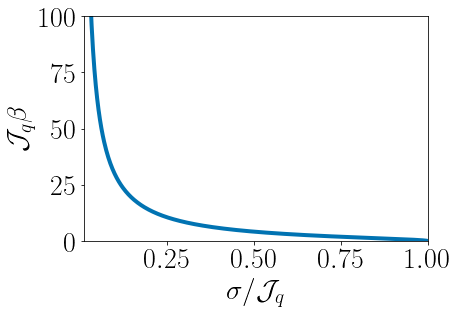

In [4]:
x = np.linspace(10**(-5), 1, 500)
beta_J = (2/x)*np.arccos(x)
E =  - np.sqrt(1-x**2) 


fig,ax = plt.subplots(1,1, figsize=(bwidth,bheight))

ax.plot(x ,beta_J, linewidth=4)
ax.set_ylabel(r'$\mathcal{J}_q\beta$')
ax.set_xlabel(r'$\sigma / \mathcal{J}_q$')
ax.set_xlim(1/100,1)
ax.set_ylim(0,100)
plt.tight_layout()

plt.savefig(fig_route+'energy_noquench_a.pdf')

fig,ax = plt.subplots(1,1, figsize=(bwidth,bheight))
ax.plot(beta_J ,E, linewidth=4)
ax.set_ylabel(r'$\mathcal{E}$/$\mathcal{J}_q$')
ax.set_xlabel(r'$\mathcal{J}_q\beta$')
ax.set_xscale('log')

plt.tight_layout()

plt.savefig(fig_route+'energy_noquench_b.pdf')



## Kinetic Quench


In [ ]:
t = np.linspace(-10, 10, 100)
E =  np.zeros(len(t))
origin_i = int(len(E)*0.5)

x = 0.74/1.0
E[:origin_i] =  - np.sqrt(1-x**2) 

fig,ax = plt.subplots(1,1, figsize=(bwidth,bheight))


ax.plot(t, E, linewidth=5 ,c ='black')
ax.axvline(0, linewidth=5, c='grey', linestyle='dotted')

ax.set_ylim(-1.1, 0.1)
ax.set_ylabel(r'$\mathcal{E}(t_1)/\mathcal{J}_q$')
ax.set_xlabel(r'$t_1$')
plt.tight_layout()
plt.savefig(fig_route+'kinetic_g_energy.pdf')


# Chapter 4: Numerical solution

For the causal stepping

In [ ]:
x = y = np.arange(-10,11,step=2)

X, Y = np.meshgrid(x, y)

fig,ax = plt.subplots(1,1, figsize=(bwidth,bwidth))

plt.scatter(X,Y, color='grey',s=7)
plt.plot(x,y, linewidth = 1.5, color='black')
plt.vlines(6,-10,6, linewidth = 1.5, color='black')
plt.hlines(6,-10,6, linewidth = 1.5, color='black')


# draw the diagonal shade
plt.plot(x[7:],y[7:], linewidth = 15, color='deepskyblue',alpha=0.5,zorder=1)
# Create a Rectangle patch
rect = patches.Rectangle((-10, -10), 14, 14, linewidth=1, edgecolor='deepskyblue', facecolor='deepskyblue',
                        alpha=0.5,zorder=1)
# Add the patch to the Axes
ax.add_patch(rect)

# set the labels
ax.set_ylabel(r'$t_2$',loc='top', labelpad=10)
ax.set_xlabel(r'$t_1$',loc='right', labelpad=-14)

# putting the axis lines in the middle
ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')

# remove the spines on the side
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# format the ticks
ax.set_xticks([4,6],[r'$t_n$', r'$t_{n+1}$'],fontsize=base_font-4,zorder=7)
ax.set_yticks([],[])
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')


# plot axis arrows
ax.plot((1), (0), ls="", marker=">", ms=10, color="k",
            transform=ax.get_yaxis_transform(), clip_on=False)

ax.plot((0), (1), ls="", marker="^", ms=10, color="k",
            transform=ax.get_xaxis_transform(), clip_on=False)

# plot arrows poting to tn+1
plt.arrow(4, -8, 1.9, 0., length_includes_head=True,
          head_width=0.5, head_length=0.5,fc='black')

plt.arrow(4, -4, 1.9, 0., length_includes_head=True,
          head_width=0.5, head_length=0.5,fc='black')

plt.arrow(4, 2, 1.9, 0., length_includes_head=True,
          head_width=0.5, head_length=0.5,fc='black')

plt.tight_layout()

plt.savefig(fig_route+'causal_stepping.pdf')


# Chapter 5: Results

## 5.1 Benchmarking with limiting cases

### For the No-quench case
1. energy graph for several temperatures showing the error and the fact that energy is constant
2. Example heatmap of what the solution looks lie
3. for the above also an MSE heatmap?

In [ ]:
data_route = 'datasets/predictor_corrector/no_quench/'


names_list = [
            "pred_sigma0.030000_Jtwo0.000000_J1.000000_dt0.050000_origin1000_mint-50.000000_maxt50.000000.h5",
            "pred_sigma0.740000_Jtwo0.000000_J1.000000_dt0.050000_origin1000_mint-50.000000_maxt50.000000.h5",
            "pred_sigma0.990000_Jtwo0.000000_J1.000000_dt0.050000_origin1000_mint-50.000000_maxt50.000000.h5"
            ]

beta0_list = []
sigma_list = []
tot_E_list = [] # for the energy as a fucntion of time
gn_list = []
predE_list = [] # for the predicted and true energy
trueE_list = []
Eperc_error_list = [] # for the percentage error in the energy
max_DE_list = [] # maximum change in energy
Re_serror_list = [] # for the mean squared error in the post-quench quadrants A and B
Im_serror_list = []

for name in names_list:
    # load and prepare the data for the energy caluclation
    gn , sig, J2, Jq, dt, origin_i, mint, maxt =  kb.initialize_data(data_route,name,use_h5=True)
    theta = np.arccos(sig/Jq[0])
    print("final J2=", J2[-1]," final Jq=", Jq[-1], " dt=",dt, " min time=",mint, " max time=",maxt)
    beta0 = 2*theta*Jq[0]/sig
    print("initial beta =", beta0)
    Et1, Ekin, Eq = kb.calculate_energy(origin_i, gn, Jq, J2,dt,sig)
    # now calculate the squared errors w.r.t the exact solution
    
    # Plot an example of the absolute squared errors with med temperature 
    time_range = np.linspace(mint,maxt,len(gn))
    t1,t2 = np.meshgrid(time_range,time_range)
    # plot the MSE between the true and calculated functions for the sigma=0.74 case
    g_true = eq_g(t1,t2,sig, Jq)
    Rerr = np.mean((g_true[:,origin_i:].real-gn[:,origin_i:].real))**2
    Imerr = np.mean((g_true[:,origin_i:].imag-gn[:,origin_i:].imag))**2

    beta0_list.append(beta0)
    tot_E_list.append(Et1)
    gn_list.append(gn)
    sigma_list.append(sig)
    Re_serror_list.append(Rerr)
    Im_serror_list.append(Imerr)    

#  plot the energies

fig, ax = plt.subplots(1,1,figsize=(bwidth,bheight))
#plt.suptitle('$\mathcal{{J}}_q=$ {}, $\mathcal{{J}}_2$ = {}, $\sigma$  ={}'.format(Jq[-1], J2[-1],sig))

print('')
for i in range(0,len(tot_E_list)):
    # ploting the energy ------------------------------------------------------
    # the true value of the energy is saved in the first value of the array
    current_E = tot_E_list[i]
    E_true = current_E[0]
    ax.axhline(E_true, c='darkgrey', linewidth=4)
    ax.plot(time_range, current_E.real,linewidth=6, 
            label=r'$\mathcal{{J}}_q\beta_{{0}}={:.1f}$'.format(beta0_list[i]),linestyle='dashed',zorder=4)
    # calculate predicted energy
    pred_E = current_E[origin_i+2:].mean()
    # calculate the change in the energy
    DE = np.diff(Et1.real, n=1)
    DE_rel = np.abs(np.divide(DE, Et1[1:].real)) # percent change
    meanDE = DE[-100:].mean()
    maxDE = DE[origin_i:].max()
    print('Energy and percentage Error for beta0 = {:.1f} ----------'.format(beta0_list[i]))
    perc_error = np.abs(pred_E-E_true)/E_true
    print('mean change in E = ', meanDE, "max change in E=",maxDE)
    print(pred_E, perc_error)
    print('')
    
    Eperc_error_list.append(perc_error)
    max_DE_list.append(maxDE)
    predE_list.append(pred_E)
    trueE_list.append(E_true)
    
ax.set_ylabel(r'$\mathcal{E}(t_1)$')
ax.set_xlabel(r'$t_1$')
ax.legend(fontsize=base_font-5)
ax.set_ylim(-1.1,0)
plt.tight_layout()

plt.savefig(fig_route+'bench_energy_noquench.pdf',bbox_inches='tight')


In [ ]:

# create a dictionary to generate and export a latex table
noquench_dict = {r'$\beta_0$':beta0_list,r'$E_{\text{pred}}$':predE_list, 
                 r'\% $E_{\text{error}}$':Eperc_error_list, 
                 r'$\Delta E(t)_{\text{max}}$':max_DE_list, r'MSE(Re[$g(t_1,t_2)$])':Re_serror_list, 
                 'MSE(Im[$g(t_1,t_2)$])':Im_serror_list}

noquench_df = pd.DataFrame(noquench_dict)

c_string = '|'+'c|'*len(noquench_df.columns)


print(noquench_df.style.format(custom_format).hide(axis='index').to_latex(
                position_float="centering",column_format=c_string ))

noquench_df

In [ ]:
# plot the one for medium temperature since it is our proptotypical example
fig, ax = component_contour(gn_list[1].real, mint, maxt,bwidth=bwidth, 
                            axis_font=base_font+13);

ax.set_title(r'$\rm{Re}[g(t_1,t_2)]$', fontsize=base_font+15)
ax.annotate('A', xy=(25,25),fontsize=base_font+15,c='green')
ax.annotate('B', xy=(-25,25),fontsize=base_font+15,c='green')
ax.annotate('C', xy=(-25,-25),fontsize=base_font+15,c='green')
ax.annotate('D', xy=(25,-25),fontsize=base_font+15,c='green')

plt.tight_layout()

plt.savefig(fig_route+'bench_Regn_noquench.png',bbox_inches='tight',dpi=200)

fig, ax = component_contour(gn_list[1].imag, mint, maxt, axis_font=base_font+13);
ax.set_title(r'$\rm{Im}[g(t_1,t_2)]$', fontsize=base_font+15)
plt.tight_layout()

plt.savefig(fig_route+'bench_Imgn_noquench.png',bbox_inches='tight',dpi=200)


In [ ]:
# Plot an example of the absolute squared errors with med temperature 
t1,t2 = np.meshgrid(time_range,time_range)
# plot the MSE between the true and calculated functions for the sigma=0.74 case
g_true = eq_g(t1,t2,sigma_list[1], Jq)
errs = np.abs((g_true-gn_list[1]))**2

fig, ax = plt.subplots(1,1, figsize=(bwidth+0.5,bwidth))
im = ax.contourf(errs, extent=[mint, maxt,mint,maxt])
ax.scatter(0,0, c='grey',s=50)
ax.axvline(0, c='grey',linewidth=2, linestyle='dashed')
ax.axhline(0, c='grey',linewidth=2, linestyle='dashed')

#cbar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar = fig.colorbar(im, cax, shrink=0.9)
cbar.ax.tick_params(labelsize=base_font+6)
# aesthetics
ax.set_title(r'$\rm{Err}[g(t_1,t_2)]$', fontsize=base_font+15)
ax.set_ylabel(r'$t_2$', fontsize=base_font+13)
ax.set_xlabel(r'$t_1$',fontsize=base_font+13)
ax.tick_params(axis='both', which='major', labelsize = base_font+7)
ax.tick_params(axis='both', which='minor', labelsize=base_font+6)

plt.tight_layout()

plt.savefig(fig_route+'bench_Errgn_noquench.png',bbox_inches='tight',dpi=200)


### For the Kinetic Quench case

In [ ]:

data_route = 'datasets/predictor_corrector/kinetic_quench/'

names_list = [
    "pred_sigma0.740000_Jtwo0.010000_J0.000000_dt0.050000_origin1000_mint-50.000000_maxt50.000000.h5",
    "pred_sigma0.740000_Jtwo0.100000_J0.000000_dt0.050000_origin1000_mint-50.000000_maxt50.000000.h5",
    "pred_sigma0.740000_Jtwo0.200000_J0.000000_dt0.050000_origin1000_mint-50.000000_maxt50.000000.h5",
    "pred_sigma0.740000_Jtwo1.000000_J0.000000_dt0.050000_origin1000_mint-50.000000_maxt50.000000.h5",
    "pred_sigma0.740000_Jtwo1.000000_J0.000000_dt0.030000_origin1700_mint-51.000000_maxt50.400000.h5",
    "pred_sigma0.030000_Jtwo0.010000_J0.000000_dt0.050000_origin1000_mint-50.000000_maxt50.000000.h5",
    "pred_sigma0.030000_Jtwo0.100000_J0.000000_dt0.050000_origin1000_mint-50.000000_maxt50.000000.h5",
    "pred_sigma0.030000_Jtwo0.200000_J0.000000_dt0.050000_origin1000_mint-50.000000_maxt50.000000.h5",
    "pred_sigma0.030000_Jtwo1.000000_J0.000000_dt0.050000_origin1000_mint-50.000000_maxt50.000000.h5",
    "pred_sigma0.900000_Jtwo0.010000_J0.000000_dt0.050000_origin1000_mint-50.000000_maxt50.000000.h5",
    "pred_sigma0.900000_Jtwo0.100000_J0.000000_dt0.050000_origin1000_mint-50.000000_maxt50.000000.h5",
    "pred_sigma0.900000_Jtwo0.200000_J0.000000_dt0.050000_origin1000_mint-50.000000_maxt50.000000.h5",
    "pred_sigma0.900000_Jtwo1.000000_J0.000000_dt0.050000_origin1000_mint-50.000000_maxt50.000000.h5"
    
    
            ]

beta0_list = []
tot_E_list = []
kin_E_list = []
int_E_list = []
sig_list = []
mint_list = []
J2_list = []
gn_list = []
dt_list = []


pred_E_list = []
max_DE_list = []
Re_serror_list = []
Im_serror_list = []

for name in names_list:
    # load and prepare the data for the energy caluclation
    gn , sig, J2, Jq, dt, origin_i, mint, maxt =  kb.initialize_data(data_route,name,use_h5=True)
    theta = np.arccos(sig/Jq[0])
    print("final J2=", J2[-1]," final Jq=", Jq[-1], " dt=",dt, " min time=",mint, " max time=",maxt)
    beta0 = 2*theta*Jq[0]/sig
    print("initial beta =", beta0)
    time_range = np.linspace(mint,maxt,len(gn))
     
    # get the errors from the energy ------------------
    Et1, Ekin, Eq = kb.calculate_energy(origin_i, gn, Jq, J2,dt,sig)
    pred_E = Et1[origin_i+2:].mean()
    DE = np.diff(Et1.real, n=1)
    DE_rel = np.abs(DE)
    maxDE = DE_rel[origin_i+2:].max()
    
    # get the mse from the known solutions ------------------
    g_true = np.zeros(np.shape(gn), dtype=complex)
    J2_magnitude = J2[-1]
    J_preq = 1.0
    t1,t2 = np.meshgrid(time_range,time_range)

    # Get the MSE between the true and calculated g's
    g_true[:origin_i,:origin_i] = eq_g(t1[:origin_i,:origin_i],
                                       t2[:origin_i,:origin_i],sig ,J_preq)

    # Quad B
    g_true[:origin_i, origin_i:] =  -(J2_magnitude**2) *t1[:origin_i, origin_i:]**2 + 2*np.log(
                                            sig/(J_preq*np.cosh(1j*theta - 
                                                sig*t2[:origin_i, origin_i:])))
    # Quad D
    g_true[origin_i:, :origin_i] = np.conj(g_true[:origin_i, origin_i:].T )

    # quad A
    g_true[origin_i:,origin_i:] = (-J2_magnitude**2)*(t1[origin_i:,origin_i:]-
                                                      t2[origin_i:,origin_i:])**2 + 1j*0
    # MSE for each component
    Rerr = np.mean((g_true[:,origin_i:].real-gn[:,origin_i:].real))**2
    Imerr = np.mean((g_true[:,origin_i:].imag-gn[:,origin_i:].imag))**2
    
    beta0_list.append(beta0)
    tot_E_list.append(Et1)
    kin_E_list.append(Ekin)
    int_E_list.append(Eq)
    gn_list.append(gn)
    J2_list.append(J2[-1])
    sig_list.append(sig)
    mint_list.append(mint)
    pred_E_list.append(pred_E)
    max_DE_list.append(maxDE)
    Re_serror_list.append(Rerr)
    Im_serror_list.append(Imerr)
    dt_list.append(dt)
    

In [ ]:
# generate latex table for the error metrics

# create the latex format for tables
kinquench_dict = {r'$\beta_0$':beta0_list, r'$\mathcal{J}_2$':J2_list, r'$\Delta t$':dt_list,
                  r'$E_{\text{pred}}$':pred_E_list, r'$\Delta E(t)_{\text{max}}$':max_DE_list, 
                  r'MSE(Re[$g(t_1,t_2)$])':Re_serror_list, 'MSE(Im[$g(t_1,t_2)$])':Im_serror_list}

kinquench_df = pd.DataFrame(kinquench_dict)
c_string = '|'+'c|'*len(kinquench_df.columns)
                 

print(kinquench_df.style.format(custom_format).hide(axis='index').to_latex(
                position_float="centering",column_format=c_string ))

kinquench_df

In [ ]:
# index for the chosen quench 
chosen_i = 1

# plot the one for medium temperature since it is our proptotypical example
fig, ax = component_contour(gn_list[chosen_i].real, mint, maxt,bwidth=bwidth, 
                            axis_font=base_font+13);
ax.set_title(r'$\rm{Re}[g(t_1,t_2)]$', fontsize=base_font+15)
ax.annotate('A', xy=(25,25),fontsize=base_font+15,c='green')
ax.annotate('B', xy=(-25,25),fontsize=base_font+15,c='green')
ax.annotate('C', xy=(-25,-25),fontsize=base_font+15,c='green')
ax.annotate('D', xy=(25,-25),fontsize=base_font+15,c='green')
plt.tight_layout()

plt.savefig(fig_route+'bench_Regn_kinquench.png',bbox_inches='tight',dpi=200)

fig, ax = component_contour(gn_list[chosen_i].imag, mint, maxt, axis_font=base_font+13);
ax.set_title(r'$\rm{Im}[g(t_1,t_2)]$', fontsize=base_font+15)
plt.tight_layout()
plt.savefig(fig_route+'bench_Imgn_kinquench.png',bbox_inches='tight',dpi=200)


In [ ]:
# clculate the true one for the errors
g_true = np.zeros(np.shape(gn), dtype=complex)
J2_magnitude = J2_list[chosen_i]
sig = sig_list[chosen_i]
J_preq = 1.0
theta = np.arccos(sig/Jq[0])

g_true[:origin_i,:origin_i] = eq_g(t1[:origin_i,:origin_i],
                                   t2[:origin_i,:origin_i],sig ,J_preq)

# Quad B
g_true[:origin_i, origin_i:] =  -(J2_magnitude**2) *t1[:origin_i, origin_i:]**2 + 2*np.log(
                                        sig/(J_preq*np.cosh(1j*theta - 
                                            sig*t2[:origin_i, origin_i:])))
# Quad D
g_true[origin_i:, :origin_i] = np.conj(g_true[:origin_i, origin_i:].T )

# quad A
g_true[origin_i:,origin_i:] = (-J2_magnitude**2)*(t1[origin_i:,origin_i:]-
                                                  t2[origin_i:,origin_i:])**2 + 1j*0

t1,t2 = np.meshgrid(time_range,time_range)
# plot the MSE between the true and calculated functions for the sigma=0.74 case
errs = np.abs((g_true-gn_list[chosen_i]))**2

fig, ax = plt.subplots(1,1, figsize=(bwidth+0.5,bwidth))
im = ax.contourf(errs, extent=[mint, maxt,mint,maxt])
ax.scatter(0,0, c='grey',s=50)
ax.axvline(0, c='grey',linewidth=2, linestyle='dashed')
ax.axhline(0, c='grey',linewidth=2, linestyle='dashed')

# for scientific notation
cbformat = matplotlib.ticker.ScalarFormatter()   # create the formatter
cbformat.set_powerlimits((-2,2))   
#cbar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar = fig.colorbar(im, cax, shrink=0.9,format=cbformat)

# aesthetics
ax.set_title(r'$\rm{Err}[g(t_1,t_2)]$', fontsize=base_font+14)
ax.set_ylabel(r'$t_2$', fontsize=base_font+13)
ax.set_xlabel(r'$t_1$',fontsize=base_font+13)
ax.tick_params(axis='both', which='major', labelsize = base_font+7)
ax.tick_params(axis='both', which='minor', labelsize=base_font+6)
cbar.ax.tick_params(labelsize=base_font+6)

plt.tight_layout()

plt.savefig(fig_route+'bench_Errgn_kinquench.png', bbox_inches='tight',dpi=200)


In [ ]:
# calculating the energy
pre_E = - Jq[0] * np.sqrt(1- (sig/Jq[0])**2) # prequench energy 
# calculate the change in the energy
time_range = np.linspace(mint,maxt,len(gn))
# the estimated part of interest is the one after the quench 
estimated_E = np.mean(Et1[-500:-1])

fig, ax = plt.subplots(1,1,figsize=(bwidth,bheight))
#plt.suptitle('$\mathcal{{J}}_q=$ {}, $\mathcal{{J}}_2$ = {}, $\sigma$  ={}'.format(Jq[-1], J2[-1],sig))

# ploting the energy ------------------------------------------------------
plot_from = 1 # index indicating first time step for the enrgy plot
ax.plot(time_range, tot_E_list[chosen_i].real,linewidth=6, 
        c='black', label=r'$\mathcal{E}(t_1)$')
ax.plot(time_range, int_E_list[chosen_i].real,linewidth=5, c='red', 
        linestyle='dotted',label=r'$\mathcal{V}(t_1)$')
ax.plot(time_range, kin_E_list[chosen_i].real,linewidth=5, c='blue',
        linestyle ='dashed', label=r'$\mathcal{K}(t_1)$')

ax.annotate(r'$\mathcal{{J}}_2={}$'.format(J2_magnitude), (-45,-0.2))
ax.set_ylabel(r'$\mathcal{E}(t_1)$')
ax.set_xlabel(r'$t_1$')
ax.legend(fontsize=base_font-8)
plt.tight_layout()

plt.savefig(fig_route+'Ecomp_kinquench.pdf')


In [ ]:
fig, ax = plt.subplots(1,1,figsize=(bwidth,bheight))
#plt.suptitle('$\mathcal{{J}}_q=$ {}, $\mathcal{{J}}_2$ = {}, $\sigma$  ={}'.format(Jq[-1], J2[-1],sig))
l_widths = [7,5,3 ,2]

# grab only the ones with different temperature a tsame J2
tot_E_list_reduced = [1, 6, 10]
beta_0 = [102.72, 1.99, 1.00]
for i in range(0,len(tot_E_list_reduced)):
    # ploting the energy ------------------------------------------------------
    # the true value of the energy is saved in the first value of the array
    current_E = tot_E_list[tot_E_list_reduced[i]]
    E_true = current_E[0]
    ax.plot(time_range, current_E.real,linewidth=l_widths[i], 
            label=r'$\mathcal{{J}}_q\beta_0={:.1f}$'.format(beta_0[i]),linestyle='solid',
            zorder=4)
    pred_E = current_E[origin_i+2:].mean()
    # calculate the change in the energy
    DE = np.diff(Et1.real, n=1)
    DE_rel = np.abs(DE) # change in E
    meanDE = DE_rel[-100:].mean()
    maxDE = DE_rel[origin_i+2:].max()
    print('Energy and (diff) Error for J2 = {:.3f} ----------'.format(J2_list[i]))
    perc_error = np.abs(pred_E-E_true)
    print('mean change in E = ', meanDE, "max change in E=",maxDE)
    print(pred_E, perc_error)
    print('')
    

ax.set_ylabel(r'$\mathcal{E}(t_1)$')
ax.set_xlabel(r'$t_1$')
ax.legend(fontsize=base_font-7)
ax.set_ylim(-1.1,0.1)
plt.tight_layout()
plt.savefig(fig_route+'Etot_kinquench.pdf')


## Error analysis of Mixed-SYK

These graphs show examples of the two timep plane and the green's function in the stationary limit to get a feel of how this solutions maky look like

In [ ]:
data_route = "datasets/predictor_corrector/medium_T/"
#name_str = "pred_sigma0.300000_Jtwo0.060000_J1.000000_dt0.050000_origin2000_mint-100.000000_maxt1000.000000.h5"
#name_str = "pred_sigma0.300000_Jtwo0.090000_J1.000000_dt0.050000_origin2000_mint-100.000000_maxt1000.000000.h5"
name_str = "pred_sigma0.740000_Jtwo0.006000_J1.000000_dt0.070000_origin1500_mint-105.000000_maxt1855.000000.npy"


gn , sig, J2, Jq, dt, origin_i, mint, maxt =  kb.initialize_data(data_route,name_str,use_h5=False)
theta = np.arccos(sig/Jq[0])
beta0 = 2*theta*Jq[0]/sig
print("initial beta =", beta0)
Et1, Ekin, Eq = kb.calculate_energy(origin_i, gn, Jq, J2,dt,sig)
time_range = np.linspace(mint,maxt,len(gn))



In [ ]:
print("total energy")
print(Et1[0])

In [ ]:
# index for the chosen quench 
chosen_i = 1

# plot the one for medium temperature since it is our proptotypical example
fig, ax = component_contour(gn.real, mint, maxt,bwidth=bwidth, 
                            axis_font=base_font+13);
ax.set_title(r'$\rm{Re}[g(t_1,t_2)]$', fontsize=base_font+15)
ax.annotate('A', xy=(500,500),fontsize=base_font+15,c='green')
#ax.annotate('B', xy=(-25,25),fontsize=base_font+15,c='green')
#ax.annotate('C', xy=(-25,-25),fontsize=base_font+15,c='green')
#ax.annotate('D', xy=(25,-25),fontsize=base_font+15,c='green')

ax.xaxis.set_major_locator(ticker.MultipleLocator(500))
plt.tight_layout()

plt.savefig(fig_route+'mixed_Reg_two_time_Jtwo{}.png'.format(J2[-1]),bbox_inches='tight',dpi=200)

fig, ax = component_contour(gn.imag, mint, maxt, axis_font=base_font+13);
ax.set_title(r'$\rm{Im}[g(t_1,t_2)]$', fontsize=base_font+15)
ax.xaxis.set_major_locator(ticker.MultipleLocator(500))

plt.tight_layout()

plt.savefig(fig_route+'mixed_Imeg_two_time_Jtwo{}.png'.format(J2[-1]),bbox_inches='tight',dpi=200)


### Calculate and plot the energy

In [ ]:
# calculating the energy
pre_E = - Jq[0] * np.sqrt(1- (sig/Jq[0])**2) # prequench energy 
# calculate the change in the energy
time_range = np.linspace(mint,maxt,len(gn))

# get the errors from the energy ------------------
Et1, Ekin, Eq = kb.calculate_energy(origin_i, gn, Jq, J2,dt,sig)
pred_E = Et1[origin_i+2:].mean()
DE = np.diff(Et1.real, n=1)
DE_rel = np.abs(DE)
maxDE = DE_rel[origin_i+2:].max()


In [ ]:
# the estimated part of interest is the one after the quench 
estimated_E = np.mean(Et1[-500:-1])

fig, ax = plt.subplots(1,1,figsize=(1.3*bwidth,bheight))

# ploting the energy ------------------------------------------------------
plot_from = 1 # index indicating first time step for the enrgy plot
ax.plot(time_range, Et1.real,linewidth=7, 
        c='black', label=r'$\mathcal{E}(t_1)$')
ax.plot(time_range, Ekin.real,linewidth=5, c='blue', 
        linestyle='dashed',label=r'$\mathcal{K}(t_1)$')
ax.plot(time_range, Eq.real,linewidth=5, c='red',
        linestyle ='dotted', label=r'$\mathcal{V}(t_1)$')

axchange = ax.twinx() 
axchange.plot(time_range[1:],DE, color='orange', linewidth=3, label='r$\Delta E(t_1) / E(t_1)$')

# aesthetics ------------------------
ax.annotate(r'$\mathcal{{J}}_2={}$'.format(J2[-1]), (250,-0.5))
ax.set_ylabel(r'$\mathcal{E}(t_1)$')
ax.set_xlabel(r'$t_1$')
ax.legend(fontsize=base_font-8)
axchange.set_ylabel(r'$\Delta \mathcal{E}(t_1)/\mathcal{E}(t_1)$')
axchange.set_ylim(-0.0007,0.01)

plt.tight_layout()

plt.savefig(fig_route+'E_mixed_Jtwo{}.pdf'.format(J2[-1]))

In [ ]:
# define the list of anti diagonals to plot
anti_list = np.linspace(int((len(gn) - origin_i)/2) - 500, 500, 3, dtype=int)
anti_list = [25_000,24_000,23_000, 22_000,21_000,20_000,18_000,16_000,
             14_000,12_000,10_000, 8_000,6000, 4000 ,2000, 0]

colors = plt.cm.Blues(np.linspace(0.3,1,len(anti_list)))
colors_LHS = plt.cm.Greens(np.linspace(0.3,1,len(anti_list)))
# colors_RHS = plt.cm.Oranges(np.linspace(0.3,1,len(anti_list)))

# get the g(T,t) at the maximum T and calculate thermal from this
g_tau = anti_diagonal(gn[origin_i+1:,origin_i+1:],anti_list[-1])
tzero = int(len(g_tau)/2)
# initial condition of derivative
gprime = -(-g_tau[tzero+2] + 8*g_tau[tzero+1]-8*g_tau[tzero-1]+g_tau[tzero-2])/(12*(2*dt))
g_tau = np.flip(g_tau[:tzero])
t_ = np.linspace(0,len(g_tau)*dt*2,len(g_tau))

# for the thermal solution use the derivative from NEQ as initial condition to avoid guesswork
Dt = 2*dt
tsteps = len(g_tau)
ialpha = gprime 
g_thermal, _,eq_time = kb.solution_to_thermal(tsteps, 0, ialpha, Dt, Jq[-1],J2[-1])
# choose the max time for plotting
max_t = -2_000

fig, ax = plt.subplots(nrows=2, sharex=True, figsize= (bwidth,2*bheight)) 
plt.subplots_adjust(hspace=.0)

# place holder for rhs lhs labels
ax[1].plot(0,0,linewidth=4,linestyle='dashed',c='orange', label=r'RHS')
ax[1].plot(0,0,linewidth=4,linestyle='solid',c=colors_LHS[-2], label=r'LHS')


# plot equilibrium solution
ax[0].plot(t_[:max_t], g_thermal[:max_t].imag,linewidth=6,  c='red',zorder=5, linestyle='dashed', 
           label=r'$g_{\beta_{f}}(t)$')


for i in range(0,len(anti_list)):
    anti = anti_list[i]
    g_tau = anti_diagonal(gn[origin_i+1:,origin_i+1:],anti_list[i])
    tzero = int(len(g_tau)/2)
    # calculate the initial condition of the derivative
    gprime = -(-g_tau[tzero+2] + 8*g_tau[tzero+1]-8*g_tau[tzero-1]+g_tau[tzero-2])/(12*(2*dt))
    g_tau = np.flip(g_tau[:tzero])
    t_ = np.linspace(0,len(g_tau)*dt*2,len(g_tau))

    # comparing the RHS and LHS of the thermal equation using the KB solution
    dg_lhs =  LHS(g_tau, gprime, Dt)
    g_RHS = RHS(g_tau)
    
    ax[0].plot(t_[:max_t], g_tau[:max_t].imag,linewidth=5,linestyle='solid', c=colors[i],
               label=r"$\mathcal{{T}}={:.0f}$".format(maxt*0.5 - anti*dt*0.5 ))
    ax[1].plot(t_[1:max_t],dg_lhs[:max_t].imag,linewidth=4,c=colors_LHS[i],
              label=r"$\mathcal{{T}}={:.0f}$".format(maxt*0.5 - anti*dt*0.5 ))
    ax[1].plot(t_[1:max_t],g_RHS[:max_t].imag,linewidth=4,linestyle='dashed',c='orange',alpha=0.5)
    

# plot the line where the solution leaves stationarity
ax[0].axvline(350, c='black', linestyle='dotted' ,linewidth = 3)
ax[1].axvline(350, c='black', linestyle='dotted' ,linewidth = 3)


# aesthetics
ax[0].set_ylabel(r"$\rm{Im}[g(\mathcal{T}_{\rm max},t)]$")
ax[0].legend(fontsize=base_font-4.5, bbox_to_anchor=(0.98, 1.0))
ax[1].legend(fontsize=base_font-4.5, bbox_to_anchor=(0.98, 1.0))

ax[1].set_xlabel(r"$t$")
ax[1].set_ylabel(r"Im[LHS] vs Im[RHS]")
ax[1].set_ylim(-0.00002,0.00009)

# move scie notation
t = ax[1].yaxis.get_offset_text()
t.set_x(0.02)
# set number of ticks
ax[1].xaxis.set_major_locator(ticker.MultipleLocator(400))

# use logscale 
ax[0].set_xscale('log')

plt.subplots_adjust(left=0.24)

plt.savefig(fig_route+'mixed_Imgtau_stat_Jtwo{:.3f}.pdf'.format(J2[-1]),bbox_inches='tight',dpi=300)


In [ ]:
# get the g(T,t) at the maximum T and calculate thermal from this
g_tau = anti_diagonal(gn[origin_i+1:,origin_i+1:],anti_list[i])
tzero = int(len(g_tau)/2)
# initial condition of derivative
gprime = -(-g_tau[tzero+2] + 8*g_tau[tzero+1]-8*g_tau[tzero-1]+g_tau[tzero-2])/(12*(2*dt))
g_tau = np.flip(g_tau[:tzero])
t_ = np.linspace(0,len(g_tau)*dt*2,len(g_tau))

# for the thermal solution use the derivative from NEQ as initial condition to avoid guesswork
Dt = 2*dt
tsteps = len(g_tau)
ialpha = gprime 
g_thermal, _,eq_time = kb.solution_to_thermal(tsteps, 0, ialpha, Dt, Jq[-1],J2[-1])

fig, ax = plt.subplots(nrows=2, sharex=True, figsize= (bwidth,2*bheight)) 
plt.subplots_adjust(hspace=.0)

# same max time as imaginary component
ax[0].plot(t_[:max_t], g_thermal[:max_t].real,linewidth=6,  c='red',zorder=5, linestyle='dashed')

for i in range(0,len(anti_list)):
    g_tau = anti_diagonal(gn[origin_i+1:,origin_i+1:],anti_list[i])
    tzero = int(len(g_tau)/2)
    # calculate the initial condition of the derivative
    gprime = -(-g_tau[tzero+2] + 8*g_tau[tzero+1]-8*g_tau[tzero-1]+g_tau[tzero-2])/(12*(2*dt))
    g_tau = np.flip(g_tau[:tzero])
    t_ = np.linspace(0,len(g_tau)*dt*2,len(g_tau))

    # comparing the RHS and LHS of the thermal equation using the KB solution
    dg_lhs =  LHS(g_tau, gprime, Dt)
    g_RHS = RHS(g_tau)
    
    ax[0].plot(t_[:max_t], g_tau[:max_t].real,linewidth=5,linestyle='solid', c=colors[i])
    ax[1].plot(t_[1:max_t],dg_lhs[:max_t].real,linewidth=4,c=colors_LHS[i])
    ax[1].plot(t_[1:max_t],g_RHS[:max_t].real,linewidth=4,linestyle='dashed',c='orange')

# plot the line where the solution leaves stationarity
ax[0].axvline(350, c='black', linestyle='dotted' ,linewidth = 3)
ax[1].axvline(350, c='black', linestyle='dotted' ,linewidth = 3)


# aesthetics
ax[0].set_ylabel(r"$\rm{Re}[g(\mathcal{T}_{\rm max},t)]$")
# set number of ticks
ax[0].yaxis.set_major_locator(ticker.MultipleLocator(1500))

ax[1].set_xlabel(r"$t$")
ax[1].set_ylabel(r"Re[LHS] vs Re[RHS]")
# ax[1].set_ylim(-0.0163,-0.0161)  # for j2 = 0.09
# ax[1].set_ylim(-0.008,-0.006)  # for j2 = 0.06
ax[1].set_ylim(-0.0002,0.0002)  # for j2 = 0.005

ax[1].ticklabel_format(style='sci',scilimits=(-3,4),axis='both')


# move sci notation
t = ax[1].yaxis.get_offset_text()
t.set_x(0.02)
# set number of ticks
ax[1].xaxis.set_major_locator(ticker.MultipleLocator(400))

plt.subplots_adjust(left=0.24)

#plt.savefig(fig_route+'mixed_Regtau_stat_Jtwo{:.3f}.pdf'.format(J2[-1]),bbox_inches='tight',dpi=300)



### tables for errors


In [ ]:
# LOW T

data_set = '/data_sig0.3_2p_imag.csv'
im_low = pd.read_csv('data_analysis/predictor_corrector'+data_set).drop('Unnamed: 0',axis=1)
im_low = im_low.drop_duplicates()
im_low['delE'] = np.abs((im_low['E0'] - im_low['Ef'])/im_low['E0']) # pre and post quench energy error
im_low['relative_errorEth'] = np.abs( (im_low['thermal_int'] - im_low['Neq_Int'])/im_low['Neq_Int'])


latex_df = im_low[['J2','mean_dE', 'max_dE', "betaf",
                   'relative_errorEth','EGamma', 'EMSE']].copy()

# rename columns and create latex format for table
latex_df.rename(columns={'J2': r"$\mathcal{J}_2$", 
                        "mean_dE":r"$\overline{\Delta \mathcal{E}(t)}$", 
                        "max_dE": r"$\Delta \mathcal{E}(t)_{\text{max}}$",
                        "relative_errorEth": r"$\text{Err}[\mathcal{V}(\beta_f)]$",
                         "EGamma":r"$\gamma$", "EMSE":r"$\text{MSE}[\gamma]$", "betaf":r"$\beta_f$"
                    }, inplace=True)


c_string = 'c'*len(latex_df.columns)              

print(latex_df.style.format(custom_format).hide(axis='index').to_latex(
                position_float="centering",column_format=c_string ))



In [ ]:
# MED T

data_set = 'data_sig0.74_2p_imag.csv'
im_high = pd.read_csv('data_analysis/predictor_corrector/'+data_set).drop('Unnamed: 0',axis=1)
im_high = im_high.drop_duplicates()
im_high = im_high[im_high['J2']!=0.1]
im_high['delE'] = np.abs((im_high['E0'] - im_high['Ef'])/im_high['E0']) # pre and post quench energy error
im_high['relative_errorEth'] = np.abs( (im_high['thermal_int'] - im_high['Neq_Int'])/im_high['Neq_Int'])


latex_df = im_high[['J2','mean_dE', 'max_dE', "betaf",
                   'relative_errorEth','EGamma', 'EMSE']].copy()

# rename columns and create latex format for table
latex_df.rename(columns={'J2': r"$\mathcal{J}_2$", 
                        "mean_dE":r"$\overline{\Delta \mathcal{E}(t)}$", 
                        "max_dE": r"$\Delta \mathcal{E}(t)_{\text{max}}$",
                        "relative_errorEth": r"$\text{Err}[\mathcal{V}(\beta_f)]$",
                         "EGamma":r"$\gamma$", "EMSE":r"$\text{MSE}[\gamma]$", "betaf":r"$\beta_f$"
                    }, inplace=True)


c_string = 'c'*len(latex_df.columns)              

print(latex_df.style.format(custom_format).hide(axis='index').to_latex(
                position_float="centering",column_format=c_string ))


In [ ]:
# HIGH T
data_set = '/data_sig0.95_2p_imag.csv'
im_inf = pd.read_csv('data_analysis/predictor_corrector/'+data_set).drop('Unnamed: 0',axis=1)
im_inf = im_inf.drop_duplicates()
im_inf['delE'] = np.abs((im_inf['E0'] - im_inf['Ef'])/im_inf['E0']) # pre and post quench energy error

# get the crossover temperature for every set of quench parameters
im_inf['relative_errorEth'] = np.abs( (im_inf['thermal_int'] - im_inf['Neq_Int'])/im_inf['Neq_Int'])

latex_df = im_inf[['J2','mean_dE', 'max_dE', "betaf",
                   'relative_errorEth','EGamma', 'EMSE']].copy()

# rename columns and create latex format for table
latex_df.rename(columns={'J2': r"$\mathcal{J}_2$", 
                        "mean_dE":r"$\overline{\Delta \mathcal{E}(t)}$", 
                        "max_dE": r"$\Delta \mathcal{E}(t)_{\text{max}}$",
                        "relative_errorEth": r"$\text{Err}[\mathcal{V}(\beta_f)]$",
                         "EGamma":r"$\gamma$", "EMSE":r"$\text{MSE}[\gamma]$", "betaf":r"$\beta_f$"
                    }, inplace=True)


c_string = 'c'*len(latex_df.columns)              

print(latex_df.style.format(custom_format).hide(axis='index').to_latex(
                position_float="centering",column_format=c_string ))



## Thermalization Rate and Final Temperature

In [ ]:

fig, ax = plt.subplots(1,1,figsize=(1.03*bwidth,bheight))

# plot temperature as a function of kinetic coupling
sns.scatterplot(data=im_inf, x='J2', y='betaf', ax=ax, s=98,edgecolor='black',marker='s',
                label=r'$\mathcal{{J}}_q\beta_0={:.1f}$'.format(im_inf['beta0'].unique()[0]), color='green')
sns.scatterplot(data=im_low, x='J2', y='betaf', ax=ax, s=98,edgecolor='black',
                label=r'$\mathcal{{J}}_q\beta_0={:.1f}$'.format(im_low['beta0'].unique()[0]),color='royalblue')
sns.scatterplot(data=im_high, x='J2', y='betaf', ax=ax, s=95,edgecolor='black',marker='^',
                label=r'$\mathcal{{J}}_q\beta_0={:.1f}$'.format(im_high['beta0'].unique()[0]), color='orange')


ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r'$\mathcal{J}_2$')
ax.set_ylabel(r'$\mathcal{J}_q \beta_f$')
#ax.xaxis.set_major_locator(plt.MaxNLocator(10))
plt.legend(fontsize=base_font-4)
plt.tight_layout()

plt.savefig(fig_route+'final_betas_J2.pdf'.format(J2[-1]),bbox_inches='tight',dpi=300)



In [ ]:
# for the thermalization rate fits
def FL_Fit(x,m):
    return m * x**(-2) 

def NFL_Fit(x,m):
    return m * x**(-1) 

def between_Fit(x,m,lamb):
    return m * x**(-lamb) 



In [ ]:
fig,ax = plt.subplots(1,1,figsize=(1.03*bwidth,bheight))

# the inf termperature ----------------------------------------------------------------
therm_df3 = im_inf[im_inf['J2']>0.002].copy()

print(therm_df3['J2'].values)
ax.errorbar(therm_df3['betaf'], therm_df3['EGamma'], yerr=therm_df3['EMSE'], capsize=10, ecolor='green',
             barsabove=True, c='black', linestyle='dashed')
sns.scatterplot(data=therm_df3, x='betaf', y='EGamma', ax=ax, s=105,edgecolor='black',zorder=5, color='green',
                marker = "s")

# the high termperature ----------------------------------------------------------------
# therm_df3 = im_high[im_high['J2']<=0.09].copy()
therm_df3 = im_high[im_high['J2']>0.002].copy()

print(therm_df3['J2'].values)
ax.errorbar(therm_df3['betaf'], therm_df3['EGamma'], yerr=therm_df3['EMSE'], capsize=10, ecolor='orange',
             barsabove=True, c='black', linestyle='dashed')
sns.scatterplot(data=therm_df3, x='betaf', y='EGamma', ax=ax, s=105,edgecolor='black',zorder=5, color='orange',
                marker = "^")


# now the low termperature ----------------------------------------------------------------
therm_df3 = im_low[im_high['J2']>0.002].copy()

ax.errorbar(therm_df3['betaf'], therm_df3['EGamma'], yerr=therm_df3['EMSE'], capsize=10, ecolor='royalblue',
             barsabove=True, c='black', linestyle='dashed')

sns.scatterplot(data=therm_df3, x='betaf', y='EGamma', ax=ax, 
                s=105,edgecolor='black',zorder=5, color='royalblue')


# POWER LAW ESTIMATION with the energy
# ommit the last two data points because here the exponential ansatz fails
trunc_df = im_low[im_low['J2']>0.002].copy()
trunc_df2 = im_high[im_high['J2']>0.002].copy()
trunc_df3 = im_inf[im_inf['J2']>0.002].copy()

beta_curve = np.linspace(trunc_df['betaf'].min(),trunc_df['betaf'].max()+50,len(trunc_df['betaf']))
beta_curve2 = np.linspace(im_high['betaf'].min(),im_high['betaf'].max()+50,len(im_high['betaf']))
beta_curve3 = np.linspace(im_inf['betaf'].min(),im_inf['betaf'].max()+50,len(im_inf['betaf']))

# fit FL behavior
params, cov = curve_fit(FL_Fit, trunc_df['betaf'], trunc_df['EGamma'] , 0.001)
fermi_curve = FL_Fit(beta_curve, 0.0015)
 
params, cov = curve_fit(FL_Fit, trunc_df2['betaf'], trunc_df2['EGamma'] , 0.001)
fermi_curve_high = FL_Fit(beta_curve2, 0.00025)

params, cov = curve_fit(FL_Fit, trunc_df3['betaf'], trunc_df3['EGamma'] , 0.001)

fermi_curve_inf = FL_Fit(beta_curve3, 0.00004)

plt.plot(beta_curve, fermi_curve,label='FL', c='royalblue', linewidth=4)
plt.plot(beta_curve2, fermi_curve_high, c='orange', linewidth=4)
plt.plot(beta_curve3, fermi_curve_inf, c='green', linewidth=4)


print("fitting variance for FL:")
print(np.sqrt(np.diag(cov)))
# calculate the R2 

# residual sum of squares
ss_res = np.sum((trunc_df['EGamma'] - fermi_curve) ** 2)
# total sum of squares
ss_tot = np.sum((trunc_df['EGamma'] - trunc_df['EGamma'].mean())** 2)
# r-squared
r2 = 1 - (ss_res / ss_tot)
print(" R^2 for FL")
print(r2)

# fit nfl 
params, cov = curve_fit(NFL_Fit, trunc_df['betaf'], trunc_df['EGamma'] , 0.1)
nfl_curve = NFL_Fit(beta_curve,params[0])
plt.plot(beta_curve, nfl_curve, label='NFL',c='pink', linestyle='dashed',linewidth=3)

print("fitting variance for NFL:")
print(np.sqrt(np.diag(cov)))
# residual sum of squares
ss_res = np.sum((trunc_df['EGamma'] - nfl_curve) ** 2)
# total sum of squares
ss_tot = np.sum((trunc_df['EGamma'] - trunc_df['EGamma'].mean())** 2)
# r-squared
r2 = 1 - (ss_res / ss_tot)
print(" R^2 for NFL")
print(r2)


# aesthetics -------------------------------------------------------------------------------- 
ax.set_ylim(0.00001,0.1)
ax.set_xlim(0.0000005,15)
ax.set_ylabel(r'$\gamma$')
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.set_xlabel(r'$(\mathcal{J}_q\beta_f)$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize=base_font-7)

plt.tight_layout()

plt.savefig(fig_route+'thermalization_rate_betaf.pdf',bbox_inches='tight',dpi=300)


In [ ]:
# zooom in into the graph

fig,ax = plt.subplots(1,1,figsize=(1.03*bwidth,bheight))

# the inf termperature ----------------------------------------------------------------
therm_df3 = im_inf[(im_inf['J2']>0.002) & (im_inf['J2']<0.05)].copy()

print(therm_df3['J2'].values)
ax.errorbar(therm_df3['betaf'], therm_df3['EGamma'], yerr=therm_df3['EMSE'], capsize=10, ecolor='green',
             barsabove=True, c='black', linestyle='dashed')
sns.scatterplot(data=therm_df3, x='betaf', y='EGamma', ax=ax, s=105,edgecolor='black',zorder=5, color='green',
                marker = "s")

# the high termperature ----------------------------------------------------------------
# therm_df3 = im_high[im_high['J2']<=0.09].copy()
therm_df3 = im_high[(im_high['J2']>0.002) & (im_high['J2']<0.05)].copy()

print(therm_df3['J2'].values)
ax.errorbar(therm_df3['betaf'], therm_df3['EGamma'], yerr=therm_df3['EMSE'], capsize=10, ecolor='orange',
             barsabove=True, c='black', linestyle='dashed')
sns.scatterplot(data=therm_df3, x='betaf', y='EGamma', ax=ax, s=105,edgecolor='black',zorder=5, color='orange',
                marker = "^")


# now the low termperature ----------------------------------------------------------------
therm_df3 = im_low[(im_low['J2']>0.002) & (im_low['J2']<0.05)].copy()

ax.errorbar(therm_df3['betaf'], therm_df3['EGamma'], yerr=therm_df3['EMSE'], capsize=10, ecolor='royalblue',
             barsabove=True, c='black', linestyle='dashed')

sns.scatterplot(data=therm_df3, x='betaf', y='EGamma', ax=ax, 
                s=105,edgecolor='black',zorder=5, color='royalblue')


plt.plot(beta_curve, fermi_curve,label='FL', c='royalblue', linewidth=4)
plt.plot(beta_curve2, fermi_curve_high, c='orange', linewidth=4)
plt.plot(beta_curve3, fermi_curve_inf, c='green', linewidth=4)

# aesthetics -------------------------------------------------------------------------------- 
ax.set_ylim(0.00001,0.005)
ax.set_xlim(0.02,9)
ax.set_ylabel(r'$\gamma$')
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.set_xlabel(r'$(\mathcal{J}_q\beta_f)$')

ax.set_xscale('log')
ax.set_yscale('log')

plt.tight_layout()

plt.savefig(fig_route+'thermalization_rate_betaf_zoom.pdf',bbox_inches='tight',dpi=300)



### Graph showing the quality of the thermalization rate fit

Do this for several examples into one graph


In [ ]:
data_route = "datasets/predictor_corrector/low_T/"

name_list = [
    "pred_sigma0.300000_Jtwo0.090000_J1.000000_dt0.050000_origin2000_mint-100.000000_maxt1000.000000.h5",
    "pred_sigma0.300000_Jtwo0.060000_J1.000000_dt0.050000_origin2000_mint-100.000000_maxt1000.000000.h5",
    "pred_sigma0.300000_Jtwo0.010000_J1.000000_dt0.050000_origin2000_mint-100.000000_maxt1000.000000.h5",
    "pred_sigma0.300000_Jtwo0.005000_J1.000000_dt0.050000_origin2000_mint-100.000000_maxt1000.000000.h5"
            ]

fig, ax = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, figsize= (1.5*bwidth,1.5*bheight)) 
# counter for plotting axes
k = 0
# i = row,  j = col
i = j = 0
for name_str in name_list:
    # counter so i can plot stuff in the correct place
    if k==0:
        i = j = 0
    elif k==1:
        i=0
        j=1
    elif k==2:
        i=1
        j=0
    elif k==3:
        i=1
        j=1
        
    gn , sig, J2, Jq, dt, origin_i, mint, maxt =  kb.initialize_data(data_route,name_str,use_h5=True)

    beta0 = 2*theta*Jq[0]/sig
    print("initial beta =", beta0)
    Et1, Ekin, Eq = kb.calculate_energy(origin_i, gn, Jq, J2,dt,sig)
    time_range = np.linspace(mint,maxt,len(gn))
    
    # grab the fit values
    gamma_f = im_low[im_low['J2']==J2[-1]]['EGamma'].values[0]
    const_f = im_low[im_low['J2']==J2[-1]]['Econst'].values[0]
    amp_f = im_low[im_low['J2']==J2[-1]]['Eampli'].values[0]

    # calculate the fiting function
    K_fit = const_f + amp_f*np.exp(-gamma_f*time_range[origin_i:])
    # plot the total energy
    # ax[i,j].plot(time_range, Et1.real,linewidth=6, c='black')
    # plot fit function
    ax[i,j].plot(time_range[origin_i:], K_fit,linewidth=4, c='grey')
    # plot observed data
    ax[i,j].plot(time_range, Ekin.real,linewidth=5, c='blue', linestyle='dashed')
    
    # write down the J2 value
    ax[i,j].annotate(r'$\mathcal{{J}}_2={}$'.format(J2[-1]), (250,-0.5))
            
    print(i,j)
    k=k+1
# put the labels

fig.text(0.56, 0.01, r'$t_1$', ha='center')
fig.text(0.009, 0.53, r'$\mathcal{K}(t_1)$', va='center', rotation='vertical')

plt.tight_layout()

plt.savefig(fig_route+'gamma_fit_view.pdf',bbox_inches='tight',dpi=300)


### Main results but with color shading

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(1.03*bwidth,bheight))

# shade
plt.axvspan(0.0005, 0.035, color='darkturquoise', alpha=0.5, lw=0)

# plot temperature as a function of kinetic coupling
sns.scatterplot(data=im_inf, x='J2', y='betaf', ax=ax, s=98,edgecolor='black',marker='s',
                label=r'$\mathcal{{J}}_q\beta_0={:.1f}$'.format(im_inf['beta0'].unique()[0]), color='green')
sns.scatterplot(data=im_low, x='J2', y='betaf', ax=ax, s=98,edgecolor='black',
                label=r'$\mathcal{{J}}_q\beta_0={:.1f}$'.format(im_low['beta0'].unique()[0]),color='royalblue')
sns.scatterplot(data=im_high, x='J2', y='betaf', ax=ax, s=95,edgecolor='black',marker='^',
                label=r'$\mathcal{{J}}_q\beta_0={:.1f}$'.format(im_high['beta0'].unique()[0]), color='orange')


ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r'$\mathcal{J}_2$')
ax.set_ylabel(r'$\mathcal{J}_q \beta_f$')
ax.set_xlim(0.0008,0.1)

#ax.xaxis.set_major_locator(plt.MaxNLocator(10))
plt.legend(fontsize=base_font-4)

plt.tight_layout()

plt.savefig(fig_route+'final_betas_J2_shaded.pdf'.format(J2[-1]),bbox_inches='tight',dpi=300)

In [ ]:
im_high[im_high['J2']==0.03][['J2','betaf']]

In [ ]:
fig,ax = plt.subplots(1,1,figsize=(1.03*bwidth,bheight))

plt.axvspan(0.1, 16.0, color='darkturquoise', alpha=0.5, lw=0)

# the inf termperature ----------------------------------------------------------------
therm_df3 = im_inf[im_inf['J2']>0.002].copy()

print(therm_df3['J2'].values)
ax.errorbar(therm_df3['betaf'], therm_df3['EGamma'], yerr=therm_df3['EMSE'], capsize=10, ecolor='green',
             barsabove=True, c='black', linestyle='dashed')
sns.scatterplot(data=therm_df3, x='betaf', y='EGamma', ax=ax, s=105,edgecolor='black',zorder=5, color='green',
                marker = "s")

# the high termperature ----------------------------------------------------------------
# therm_df3 = im_high[im_high['J2']<=0.09].copy()
therm_df3 = im_high[im_high['J2']>0.002].copy()

print(therm_df3['J2'].values)
ax.errorbar(therm_df3['betaf'], therm_df3['EGamma'], yerr=therm_df3['EMSE'], capsize=10, ecolor='orange',
             barsabove=True, c='black', linestyle='dashed')
sns.scatterplot(data=therm_df3, x='betaf', y='EGamma', ax=ax, s=105,edgecolor='black',zorder=5, color='orange',
                marker = "^")


# now the low termperature ----------------------------------------------------------------
therm_df3 = im_low[im_high['J2']>0.002].copy()

ax.errorbar(therm_df3['betaf'], therm_df3['EGamma'], yerr=therm_df3['EMSE'], capsize=10, ecolor='royalblue',
             barsabove=True, c='black', linestyle='dashed')

sns.scatterplot(data=therm_df3, x='betaf', y='EGamma', ax=ax, 
                s=105,edgecolor='black',zorder=5, color='royalblue')


# POWER LAW ESTIMATION with the energy
# ommit the last two data points because here the exponential ansatz fails
trunc_df = im_low[im_low['J2']>0.002].copy()
trunc_df2 = im_high[im_high['J2']>0.002].copy()
trunc_df3 = im_inf[im_inf['J2']>0.002].copy()

beta_curve = np.linspace(trunc_df['betaf'].min(),trunc_df['betaf'].max()+50,len(trunc_df['betaf']))
beta_curve2 = np.linspace(im_high['betaf'].min(),im_high['betaf'].max()+50,len(im_high['betaf']))
beta_curve3 = np.linspace(im_inf['betaf'].min(),im_inf['betaf'].max()+50,len(im_inf['betaf']))

# fit FL behavior
params, cov = curve_fit(FL_Fit, trunc_df['betaf'], trunc_df['EGamma'] , 0.001)
fermi_curve = FL_Fit(beta_curve, 0.0015)
 
params, cov = curve_fit(FL_Fit, trunc_df2['betaf'], trunc_df2['EGamma'] , 0.001)
fermi_curve_high = FL_Fit(beta_curve2, 0.00025)

params, cov = curve_fit(FL_Fit, trunc_df3['betaf'], trunc_df3['EGamma'] , 0.001)

fermi_curve_inf = FL_Fit(beta_curve3, 0.00004)

plt.plot(beta_curve, fermi_curve,label='FL', c='royalblue', linewidth=4)
plt.plot(beta_curve2, fermi_curve_high, c='orange', linewidth=4)
plt.plot(beta_curve3, fermi_curve_inf, c='green', linewidth=4)


print("fitting variance for FL:")
print(np.sqrt(np.diag(cov)))
# calculate the R2 

# residual sum of squares
ss_res = np.sum((trunc_df['EGamma'] - fermi_curve) ** 2)
# total sum of squares
ss_tot = np.sum((trunc_df['EGamma'] - trunc_df['EGamma'].mean())** 2)
# r-squared
r2 = 1 - (ss_res / ss_tot)
print(" R^2 for FL")
print(r2)

# fit nfl 
params, cov = curve_fit(NFL_Fit, trunc_df['betaf'], trunc_df['EGamma'] , 0.1)
nfl_curve = NFL_Fit(beta_curve,params[0])
plt.plot(beta_curve, nfl_curve, label='NFL',c='pink', linestyle='dashed',linewidth=3)

print("fitting variance for NFL:")
print(np.sqrt(np.diag(cov)))
# residual sum of squares
ss_res = np.sum((trunc_df['EGamma'] - nfl_curve) ** 2)
# total sum of squares
ss_tot = np.sum((trunc_df['EGamma'] - trunc_df['EGamma'].mean())** 2)
# r-squared
r2 = 1 - (ss_res / ss_tot)
print(" R^2 for NFL")
print(r2)


# aesthetics -------------------------------------------------------------------------------- 
ax.set_ylim(0.00001,0.1)
ax.set_xlim(0.0000005,15)
ax.set_ylabel(r'$\gamma$')
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.set_xlabel(r'$(\mathcal{J}_q\beta_f)$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize=base_font-7)

plt.tight_layout()

plt.savefig(fig_route+'thermalization_rate_betaf_shaded.pdf',bbox_inches='tight',dpi=300)


In [ ]:
# zooom in into the graph

fig,ax = plt.subplots(1,1,figsize=(1.03*bwidth,bheight))

# shade
plt.axvspan(0.1, 16.0, color='darkturquoise', alpha=0.5, lw=0)


# the inf termperature ----------------------------------------------------------------
therm_df3 = im_inf[(im_inf['J2']>0.002) & (im_inf['J2']<0.05)].copy()

print(therm_df3['J2'].values)
ax.errorbar(therm_df3['betaf'], therm_df3['EGamma'], yerr=therm_df3['EMSE'], capsize=10, ecolor='green',
             barsabove=True, c='black', linestyle='dashed')
sns.scatterplot(data=therm_df3, x='betaf', y='EGamma', ax=ax, s=105,edgecolor='black',zorder=5, color='green',
                marker = "s")

# the high termperature ----------------------------------------------------------------
# therm_df3 = im_high[im_high['J2']<=0.09].copy()
therm_df3 = im_high[(im_high['J2']>0.002) & (im_high['J2']<0.05)].copy()

print(therm_df3['J2'].values)
ax.errorbar(therm_df3['betaf'], therm_df3['EGamma'], yerr=therm_df3['EMSE'], capsize=10, ecolor='orange',
             barsabove=True, c='black', linestyle='dashed')
sns.scatterplot(data=therm_df3, x='betaf', y='EGamma', ax=ax, s=105,edgecolor='black',zorder=5, color='orange',
                marker = "^")


# now the low termperature ----------------------------------------------------------------
therm_df3 = im_low[(im_low['J2']>0.002) & (im_low['J2']<0.05)].copy()

ax.errorbar(therm_df3['betaf'], therm_df3['EGamma'], yerr=therm_df3['EMSE'], capsize=10, ecolor='royalblue',
             barsabove=True, c='black', linestyle='dashed')

sns.scatterplot(data=therm_df3, x='betaf', y='EGamma', ax=ax, 
                s=105,edgecolor='black',zorder=5, color='royalblue')


plt.plot(beta_curve, fermi_curve,label='FL', c='royalblue', linewidth=4)
plt.plot(beta_curve2, fermi_curve_high, c='orange', linewidth=4)
plt.plot(beta_curve3, fermi_curve_inf, c='green', linewidth=4)

# aesthetics -------------------------------------------------------------------------------- 
ax.set_ylim(0.00001,0.005)
ax.set_xlim(0.02,9)
ax.set_ylabel(r'$\gamma$')
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.set_xlabel(r'$(\mathcal{J}_q\beta_f)$')

ax.set_xscale('log')
ax.set_yscale('log')

plt.tight_layout()

plt.savefig(fig_route+'thermalization_rate_betaf_zoom_shaded.pdf',bbox_inches='tight',dpi=300)


### Final temperature as a function of initial temperature

In [ ]:
data_set = 'data_temperatures_Jtwo.csv'
temp_df = pd.read_csv('data_analysis/predictor_corrector/'+data_set).drop('Unnamed: 0',axis=1)
temp_df = temp_df.drop_duplicates()
temp_df = temp_df[temp_df['J2']!=0.1]
temp_df['delE'] = np.abs((temp_df['E0'] - temp_df['Ef'])/temp_df['E0']) # pre and post quench energy error


print(temp_df.columns)

temp_df['relative_errorEth'] = np.abs( (temp_df['thermal_int'] - temp_df['Neq_Int'])/temp_df['Neq_Int'])

temp_df[['dt','maxt','beta0','J2','E0','betaf','Ef','thermalE','delE',
         'max_dE','mean_dE','thermal_Kin','Neq_Kin',
         'thermal_int','Neq_Int','relative_errorEth','Econst','EGamma']]

J2_mag = temp_df['J2'].unique()[0]

In [ ]:
fig,ax = plt.subplots(1,1,figsize=(1.2*bwidth,bheight+0.4))

plt.scatter(temp_df['beta0'],temp_df['betaf'], s=105, marker="D",c = 'slategray', edgecolor='black', )

plt.ylabel(r'$\mathcal{J}_q\beta_f$')
plt.xlabel(r'$\mathcal{J}_q\beta_0$')

ax.annotate("$\mathcal{{J}}_2={:.2f}$".format(J2_mag), xy=(3.5,0.4),fontsize=base_font+3)
plt.savefig(fig_route+'betaf_beta0.pdf'.format(J2[-1]),bbox_inches='tight',dpi=300)


In [ ]:
werrrrrrr

In [ ]:

folder_list = [
    "pred_sig0.3_jtwo0.005_dt0.05_jq1.0_tmax1000/",
    "pred_sig0.3_jtwo0.006_dt0.05_jq1.0_tmax1000/",
    "pred_sig0.3_jtwo0.008_dt0.05_jq1.0_tmax1000/",
    "pred_sig0.3_jtwo0.009_dt0.05_jq1.0_tmax1000/",
    "pred_sig0.3_jtwo0.04_dt0.05_jq1.0_tmax1000/",
    "pred_sig0.3_jtwo0.05_dt0.05_jq1.0_tmax1000/",
    "pred_sig0.3_jtwo0.06_dt0.05_jq1.0_tmax1000/",
    "pred_sig0.3_jtwo0.07_dt0.05_jq1.0_tmax1000/",
    "pred_sig0.3_jtwo0.08_dt0.05_jq1.0_tmax1000/",
    "pred_sig0.3_jtwo0.09_dt0.05_jq1.0_tmax1000/"
              ]

file_list = [
    "pred_sigma0.300000_Jtwo0.005000_J1.000000_dt0.050000_origin2000_mint-100.000000_maxt1000.000000.npy",
    "pred_sigma0.300000_Jtwo0.006000_J1.000000_dt0.050000_origin2000_mint-100.000000_maxt1000.000000.npy",
    "pred_sigma0.300000_Jtwo0.008000_J1.000000_dt0.050000_origin2000_mint-100.000000_maxt1000.000000.npy",
    "pred_sigma0.300000_Jtwo0.009000_J1.000000_dt0.050000_origin2000_mint-100.000000_maxt1000.000000.npy",
    "pred_sigma0.300000_Jtwo0.040000_J1.000000_dt0.050000_origin2000_mint-100.000000_maxt1000.000000.npy",
    "pred_sigma0.300000_Jtwo0.050000_J1.000000_dt0.050000_origin2000_mint-100.000000_maxt1000.000000.npy",
    "pred_sigma0.300000_Jtwo0.060000_J1.000000_dt0.050000_origin2000_mint-100.000000_maxt1000.000000.npy",
    "pred_sigma0.300000_Jtwo0.070000_J1.000000_dt0.050000_origin2000_mint-100.000000_maxt1000.000000.npy",
    "pred_sigma0.300000_Jtwo0.080000_J1.000000_dt0.050000_origin2000_mint-100.000000_maxt1000.000000.npy",
    "pred_sigma0.300000_Jtwo0.090000_J1.000000_dt0.050000_origin2000_mint-100.000000_maxt1000.000000.npy",
    "pred_sigma0.900000_Jtwo0.200000_J0.000000_dt0.050000_origin1000_mint-50.000000_maxt50.000000.npy",
    ""
]

folder_list = [
    "pred_sig0.3_jtwo0.02_dt0.05_jq1.0_tmax1000/",
    "pred_sig0.3_jtwo0.03_dt0.05_jq1.0_tmax1000/",
    "pred_sig0.3_jtwo0.04_dt0.05_jq1.0_tmax1000/",
    "pred_sig0.3_jtwo0.07_dt0.05_jq1.0_tmax1000/",
    "pred_sig0.3_jtwo0.08_dt0.05_jq1.0_tmax1000/",
    "pred_sig0.3_jtwo0.09_dt0.05_jq1.0_tmax1000/"
            ]

file_list = [
    "pred_sigma0.300000_Jtwo0.020000_J1.000000_dt0.050000_origin2000_mint-100.000000_maxt1000.000000.npy",
    "pred_sigma0.300000_Jtwo0.030000_J1.000000_dt0.050000_origin2000_mint-100.000000_maxt1000.000000.npy",
    "pred_sigma0.300000_Jtwo0.040000_J1.000000_dt0.050000_origin2000_mint-100.000000_maxt1000.000000.npy",
    "pred_sigma0.300000_Jtwo0.070000_J1.000000_dt0.050000_origin2000_mint-100.000000_maxt1000.000000.npy",
    "pred_sigma0.300000_Jtwo0.080000_J1.000000_dt0.050000_origin2000_mint-100.000000_maxt1000.000000.npy",
    "pred_sigma0.300000_Jtwo0.090000_J1.000000_dt0.050000_origin2000_mint-100.000000_maxt1000.000000.npy"
            ]


names_list = [i + j for i, j in zip(folder_list, file_list)]
for i in names_list:
    print(i)


In [ ]:
102 / 3

In [ ]:
strin = "datasets/pred_sigma0.300000_Jtwo0.006000_J1.000000_dt0.050000_origin2000_mint-100.000000_maxt1000.000000.npy"

a = np.load(strin)
ind = 1650
print(np.isnan(a[:1500+ind,:1500+ind].imag).any(), np.isnan(a[:1500+ind,:1500+ind].real).any())

dt = 0.06
print(ind*dt)


In [ ]:

# to download
